<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Importation des bibliotheques</T1>

In [20]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from Mon_module import add_bands
import numpy as np

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Chargement des donnees</T1>

In [21]:
# répertoire des données brutes :
data_dir = Path("..") / "data" / "cleaned"
csv_files = sorted([p for p in data_dir.iterdir()])

# liste de DataFrame et dict {stem: df} :
dfs = [pd.read_csv(p) for p in csv_files]
dfs_names = [p.stem for p in csv_files]
dfs_dict = dict(zip(dfs_names, dfs))

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Calcul des KPIs</T1>

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>KPI 1 : Volatilité rolling 30 jours</T1>

In [22]:
eur = dfs_dict['taux_change (EUR)_cleaned'].copy()
usd = dfs_dict['taux_change (USD)_cleaned'].copy()

eur['Date'] = pd.to_datetime(eur['Date'])
usd['Date'] = pd.to_datetime(usd['Date'])

eur = eur.sort_values('Date').set_index('Date')
usd = usd.sort_values('Date').set_index('Date')

# Volatilité rolling 30 jours (std des variations quotidiennes)
eur['KPI1_Vol_EUR'] = eur['Variation'].rolling(window=30, min_periods=15).std()
usd['KPI1_Vol_USD'] = usd['Variation'].rolling(window=30, min_periods=15).std()

# Agréger à l'année pour le fichier KPI consolidé
kpi1_eur = eur['KPI1_Vol_EUR'].resample('Y').mean().rename('KPI1_Vol_EUR_ann')
kpi1_usd = usd['KPI1_Vol_USD'].resample('Y').mean().rename('KPI1_Vol_USD_ann')

kpi1 = pd.concat([kpi1_eur, kpi1_usd], axis=1).reset_index()
kpi1['Year'] = kpi1['Date'].dt.year
kpi1 = kpi1.drop(columns='Date')

print("KPI 1 — Volatilité rolling 30 jours (moyenne annuelle) :")
display(kpi1)

KPI 1 — Volatilité rolling 30 jours (moyenne annuelle) :


,KPI1_Vol_EUR_ann,KPI1_Vol_USD_ann,Year
0,0.172423,0.612153,2010
1,0.154455,0.604794,2011
2,0.132155,0.428682,2012
3,0.123756,0.374852,2013
4,0.130273,0.322775,2014
5,0.270039,0.510012,2015
6,0.254402,0.341165,2016
7,0.232598,0.302431,2017
8,0.174096,0.278179,2018
9,0.172395,0.216653,2019


<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1> KPI 2 : Variation annuelle du taux de change</T1>

In [23]:
eur_ann = (eur['Cours'].resample('Y').mean()
           .reset_index().rename(columns={'Date':'year','Cours':'EUR_MAD_moy'}))
usd_ann = (usd['Cours'].resample('Y').mean()
           .reset_index().rename(columns={'Date':'year','Cours':'USD_MAD_moy'}))

eur_ann['Year'] = eur_ann['year'].dt.year
usd_ann['Year'] = usd_ann['year'].dt.year

eur_ann['KPI2_Var_EUR'] = eur_ann['EUR_MAD_moy'].pct_change() * 100
usd_ann['KPI2_Var_USD'] = usd_ann['USD_MAD_moy'].pct_change() * 100

kpi2 = (eur_ann[['Year','EUR_MAD_moy','KPI2_Var_EUR']]
        .merge(usd_ann[['Year','USD_MAD_moy','KPI2_Var_USD']], on='Year'))

print("KPI 2 — Variation annuelle du taux de change :")
display(kpi2.round(4))

KPI 2 — Variation annuelle du taux de change :


,Year,EUR_MAD_moy,KPI2_Var_EUR,USD_MAD_moy,KPI2_Var_USD
0,2010,11.1596,NaN,8.4260,NaN
1,2011,11.2589,0.8898,8.0933,-3.9479
2,2012,11.0976,-1.4326,8.6349,6.6909
3,2013,11.1668,0.6237,8.4083,-2.6237
4,2014,11.1643,-0.0228,8.4148,0.0777
5,2015,10.8198,-3.0861,9.7499,15.8653
6,2016,10.8514,0.2925,9.8061,0.5768
7,2017,10.9552,0.9569,9.7075,-1.0060
8,2018,11.0822,1.1593,9.3891,-3.2793
9,2019,10.7613,-2.8958,9.6176,2.4328


<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>KPI 3 & 4 : Balance commerciale et taux de couverture</T1>

KPI 3 & 4 — Balance commerciale et taux de couverture :


,Year,value_exports,value_imports,KPI3_Balance,KPI4_Tx_Couv
0,2024,6.745425e+10,8.060860e+10,-1.315436e+10,83.68
1,2023,6.194501e+10,7.404071e+10,-1.209570e+10,83.66
2,2022,5.868192e+10,7.375289e+10,-1.507097e+10,79.57
3,2021,4.706055e+10,6.019936e+10,-1.313881e+10,78.17
4,2020,3.736977e+10,4.617469e+10,-8.804922e+09,80.93
5,2019,4.395286e+10,5.402411e+10,-1.007125e+10,81.36
6,2018,4.307752e+10,5.529974e+10,-1.222222e+10,77.90
7,2017,3.865189e+10,4.927364e+10,-1.062175e+10,78.44
8,2016,3.429149e+10,4.506215e+10,-1.077066e+10,76.10
9,2015,3.311957e+10,4.117643e+10,-8.056862e+09,80.43


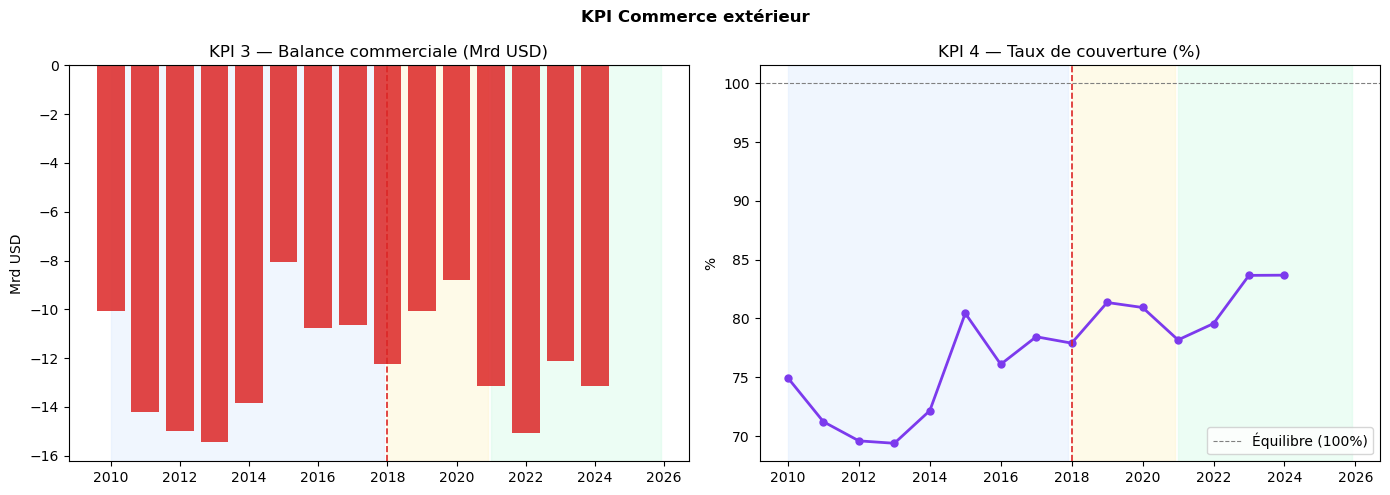

In [24]:
ice = dfs_dict['ice_global_cleaned'].copy()

ice['KPI3_Balance']    = ice['value_exports'] - ice['value_imports']
ice['KPI4_Tx_Couv']    = (ice['value_exports'] / ice['value_imports']) * 100

kpi34 = ice[['year','value_exports','value_imports',
             'KPI3_Balance','KPI4_Tx_Couv']].rename(columns={'year':'Year'})

print("KPI 3 & 4 — Balance commerciale et taux de couverture :")
display(kpi34.round(2))

# Visualisation rapide
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("KPI Commerce extérieur", fontweight='bold')

ax = axes[0]
ax.bar(kpi34['Year'], kpi34['KPI3_Balance']/1e9,
       color=['#DC2626' if v < 0 else '#1D9E75'
              for v in kpi34['KPI3_Balance']], alpha=0.85)
ax.axhline(0, color='gray', linewidth=0.8)
add_bands(ax, is_date=False)
ax.set_title("KPI 3 — Balance commerciale (Mrd USD)")
ax.set_ylabel("Mrd USD")

ax = axes[1]
ax.plot(kpi34['Year'], kpi34['KPI4_Tx_Couv'],
        color='#7C3AED', linewidth=2, marker='o', markersize=5)
ax.axhline(100, color='gray', linewidth=0.8,
           linestyle='--', label='Équilibre (100%)')
add_bands(ax, is_date=False)
ax.set_title("KPI 4 — Taux de couverture (%)")
ax.set_ylabel("%")
ax.legend()

plt.tight_layout()
plt.savefig("../visualisation/viz_kpi_commerce.png", bbox_inches='tight', dpi=150)
plt.show()

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>KPI 5 & 6 : IDE et variation</T1>

In [25]:
ide = dfs_dict['ide_global_cleaned'].copy()

kpi56 = ide[['Year','IDE_USD','FDI_growth_rate']].rename(columns={
    'IDE_USD':        'KPI5_IDE_USD',
    'FDI_growth_rate':'KPI6_Var_IDE'
})

print("KPI 5 & 6 — IDE et variation annuelle :")
display(kpi56.round(4))

KPI 5 & 6 — IDE et variation annuelle :


,Year,KPI5_IDE_USD,KPI6_Var_IDE
0,2024,1.639000e+09,NaN
1,2023,1.060024e+09,-35.3250
2,2022,2.294356e+09,116.4439
3,2021,2.264149e+09,-1.3166
4,2020,1.418713e+09,-37.3401
5,2019,1.720825e+09,21.2948
6,2018,3.544387e+09,105.9702
7,2017,2.680110e+09,-24.3844
8,2016,2.153364e+09,-19.6539
9,2015,3.252914e+09,51.0620


<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1> KPI 7 : Taux d'inflation</T1>

### ⚠️ Note — KPI 7 Inflation (correction rebasage 2020)

#### Contexte
Le HCP (Haut-Commissariat au Plan) a officiellement changé 
la base de référence de l'IPC le 20 mai 2020 :
- **Avant avril 2020** : base 2006 = 100
- **À partir d'avril 2020** : base 2017 = 100

Cette réforme a introduit plusieurs changements majeurs :
- Période de référence : 2017 au lieu de 2006
- Panier élargi : 546 articles (contre 478 précédemment)
- Couverture géographique : 18 villes / 12 régions
- Pondérations actualisées (enquête 2014)

#### Rupture identifiée dans les données
La rupture est visible entre :
- Mars 2020 : IPC = 121.3 (base 2006)
- Avril 2020 : IPC = 102.4 (base 2017)

#### Problème pour le calcul de l'inflation
La variation annuelle compare chaque mois M avec le même 
mois M-12. Pour les 12 mois entre avril 2020 et mars 2021,
cette comparaison croise les deux bases :

  Inflation avril 2020 = (102.4 / 120.2) - 1 = -14.8%  ❌
  → Compare base 2017 avec base 2006 → résultat faux

  Inflation avril 2021 = (103.8 / 102.4) - 1 = +1.37%  ✅  
  → Compare base 2017 avec base 2017 → résultat correct

#### Traitement appliqué
Les 12 mois dont la variation croise la rupture 
(avril 2020 → mars 2021) sont mis à NaN.

Impact sur les moyennes annuelles :
| Année | Mois valides | Mois NaN | Calculé sur |
|-------|-------------|----------|-------------|
| 2020  | Jan-Mar     | Avr-Déc  | 3 mois      |
| 2021  | Avr-Déc     | Jan-Mar  | 9 mois      |
| Autres| 12 mois     | 0        | 12 mois     |

#### Valeurs corrigées
- 2020 : 1.31% (au lieu de -11% erroné)
- 2021 : 1.82% (au lieu de -3% erroné)
Ces valeurs sont cohérentes avec les publications 
officielles du HCP.

#### Limite à mentionner dans le rapport final
Les valeurs 2020 et 2021 sont calculées sur des périodes
incomplètes (3 et 9 mois respectivement) et doivent être
interprétées avec précaution dans les tests statistiques.

In [26]:
ipc_c = dfs_dict['ipc_cleaned'].copy()

MOIS_NUM = {
    'janvier':1,'février':2,'mars':3,'avril':4,
    'mai':5,'juin':6,'juillet':7,'août':8,
    'septembre':9,'octobre':10,'novembre':11,'décembre':12
}
ipc_c['mois_num'] = ipc_c['mois'].map(MOIS_NUM)
ipc_c['date'] = pd.to_datetime(
    ipc_c['annee'].astype(str) + '-' +
    ipc_c['mois_num'].astype(str).str.zfill(2) + '-01'
)
ipc_c = ipc_c.sort_values('date').reset_index(drop=True)

# Marquer la base
RUPTURE = pd.Timestamp('2020-04-01')
ipc_c['base'] = ipc_c['date'].apply(
    lambda d: 'base_2006' if d < RUPTURE else 'base_2017'
)

# Calculer variation 12 mois
ipc_c['Infl_12m'] = ipc_c['Ensemble'].pct_change(12) * 100

# Annuler les variations qui croisent la rupture
# = mois d'avril 2020 à mars 2021 inclus
mask_invalide = (
    (ipc_c['date'] >= RUPTURE) &
    (ipc_c['date'] < pd.Timestamp('2021-04-01'))
)
ipc_c.loc[mask_invalide, 'Infl_12m'] = np.nan

# Vérification
print("=== Inflation mensuelle 2019-2022 ===")
mask_check = ipc_c['annee'].isin([2019, 2020, 2021, 2022])
print(ipc_c[mask_check][['date','mois','Ensemble','base','Infl_12m']].to_string())

# Moyenne annuelle
kpi7 = (ipc_c.groupby('annee')['Infl_12m']
        .mean()
        .reset_index()
        .rename(columns={'annee':'Year', 'Infl_12m':'KPI7_Inflation'}))

print("\n=== KPI7 Inflation annuelle corrigée ===")
print(kpi7.round(4).to_string())

=== Inflation mensuelle 2019-2022 ===
          date       mois  Ensemble       base  Infl_12m
108 2019-01-01    janvier     119.5  base_2006 -0.250417
109 2019-02-01    février     119.5  base_2006  0.000000
110 2019-03-01       mars     119.5  base_2006 -0.083612
111 2019-04-01      avril     120.2  base_2006  0.166667
112 2019-05-01        mai     121.0  base_2006  0.331675
113 2019-06-01       juin     121.2  base_2006  0.248139
114 2019-07-01    juillet     120.2  base_2006  0.333890
115 2019-08-01       août     120.6  base_2006  0.751880
116 2019-09-01  septembre     120.3  base_2006  0.250000
117 2019-10-01    octobre     120.7  base_2006  0.667223
118 2019-11-01   novembre     121.2  base_2006  0.414250
119 2019-12-01   décembre     121.2  base_2006  1.168614
120 2020-01-01    janvier     121.1  base_2006  1.338912
121 2020-02-01    février     120.8  base_2006  1.087866
122 2020-03-01       mars     121.3  base_2006  1.506276
123 2020-04-01      avril     102.4  base_2017    

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>KPI 8 & 9 : Réserves</T1>

In [27]:
res = dfs_dict['reserves_cleaned'].copy()

kpi89 = res[['year','value_usd','value_months']].rename(columns={
    'year':         'Year',
    'value_usd':    'KPI8_Reserves_USD',
    'value_months': 'KPI9_Mois_Couv'
})

print("KPI 8 & 9 — Réserves de change :")
display(kpi89.round(4))

KPI 8 & 9 — Réserves de change :


,Year,KPI8_Reserves_USD,KPI9_Mois_Couv
0,2024,3.713391e+10,5.2712
1,2023,3.632770e+10,5.6348
2,2022,3.231425e+10,5.0621
3,2021,3.564827e+10,6.7713
4,2020,3.599764e+10,8.9354
5,2019,2.641276e+10,5.5842
6,2018,2.446102e+10,5.0451
7,2017,2.618959e+10,6.0253
8,2016,2.509626e+10,6.3379
9,2015,2.274957e+10,6.2580


<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Consolidation de tous les KPI</T1>

In [30]:
df_kpi = (kpi2[['Year','EUR_MAD_moy','USD_MAD_moy',
                 'KPI2_Var_EUR','KPI2_Var_USD']]
    .merge(kpi1,   on='Year', how='left')
    .merge(kpi34[['Year','KPI3_Balance','KPI4_Tx_Couv']], on='Year', how='left')
    .merge(kpi56,  on='Year', how='left')
    .merge(kpi7[['Year','KPI7_Inflation']], on='Year', how='left')
    .merge(kpi89,  on='Year', how='left')
)

# Ajouter la colonne période
def get_periode(y):
    if y <= 2017:   return 'Avant (2010-2017)'
    elif y <= 2020: return 'Transition (2018-2020)'
    else:           return 'Après (2021-2025)'

df_kpi['Periode'] = df_kpi['Year'].apply(get_periode)

# Réordonner les colonnes
cols_order = [
    'Year', 'Periode',
    'EUR_MAD_moy', 'USD_MAD_moy',
    'KPI1_Vol_EUR_ann', 'KPI1_Vol_USD_ann',
    'KPI2_Var_EUR', 'KPI2_Var_USD',
    'KPI3_Balance', 'KPI4_Tx_Couv',
    'KPI5_IDE_USD', 'KPI6_Var_IDE',
    'KPI7_Inflation',
    'KPI8_Reserves_USD', 'KPI9_Mois_Couv'
]
df_kpi = df_kpi[cols_order].sort_values('Year').reset_index(drop=True)

# ── Corrections finales ──────────────────────────────────
# 1. Supprimer 2025 et 2026 (données incomplètes)
df_kpi = df_kpi[df_kpi['Year'] <= 2024].reset_index(drop=True)

# 2. KPI6 2010 = NaN (premier point, pas de référence antérieure)
df_kpi.loc[df_kpi['Year'] == 2010, 'KPI6_Var_IDE'] = np.nan

# ── Vérification ─────────────────────────────────────────
print(f"Fichier KPI consolidé : {df_kpi.shape}")
print(f"Années : {df_kpi['Year'].tolist()}")
print(f"\nVérification KPI6 et KPI7 :")
print(df_kpi[['Year','KPI6_Var_IDE','KPI7_Inflation']].to_string())

# ── Sauvegarder ──────────────────────────────────────────
df_kpi.to_csv("../data/processed/kpis_maroc.csv", index=False, encoding='utf-8-sig')
print("\nSauvegardé : data/processed/kpis_maroc.csv")

Fichier KPI consolidé : (15, 15)
Années : [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Vérification KPI6 et KPI7 :
    Year  KPI6_Var_IDE  KPI7_Inflation
0   2010           NaN             NaN
1   2011    -11.280698        0.913808
2   2012    -15.440924        1.295197
3   2013     -4.665440        1.877314
4   2014      8.376204        0.443078
5   2015     51.061968        1.560187
6   2016    -19.653894        1.634755
7   2017    -24.384395        0.757274
8   2018    105.970231        1.778451
9   2019     21.294783        0.333192
10  2020    -37.340106        1.311018
11  2021     -1.316597        1.822314
12  2022    116.443864        6.641372
13  2023    -35.324966        6.144152
14  2024           NaN        0.988983

Sauvegardé : data/processed/kpis_maroc.csv


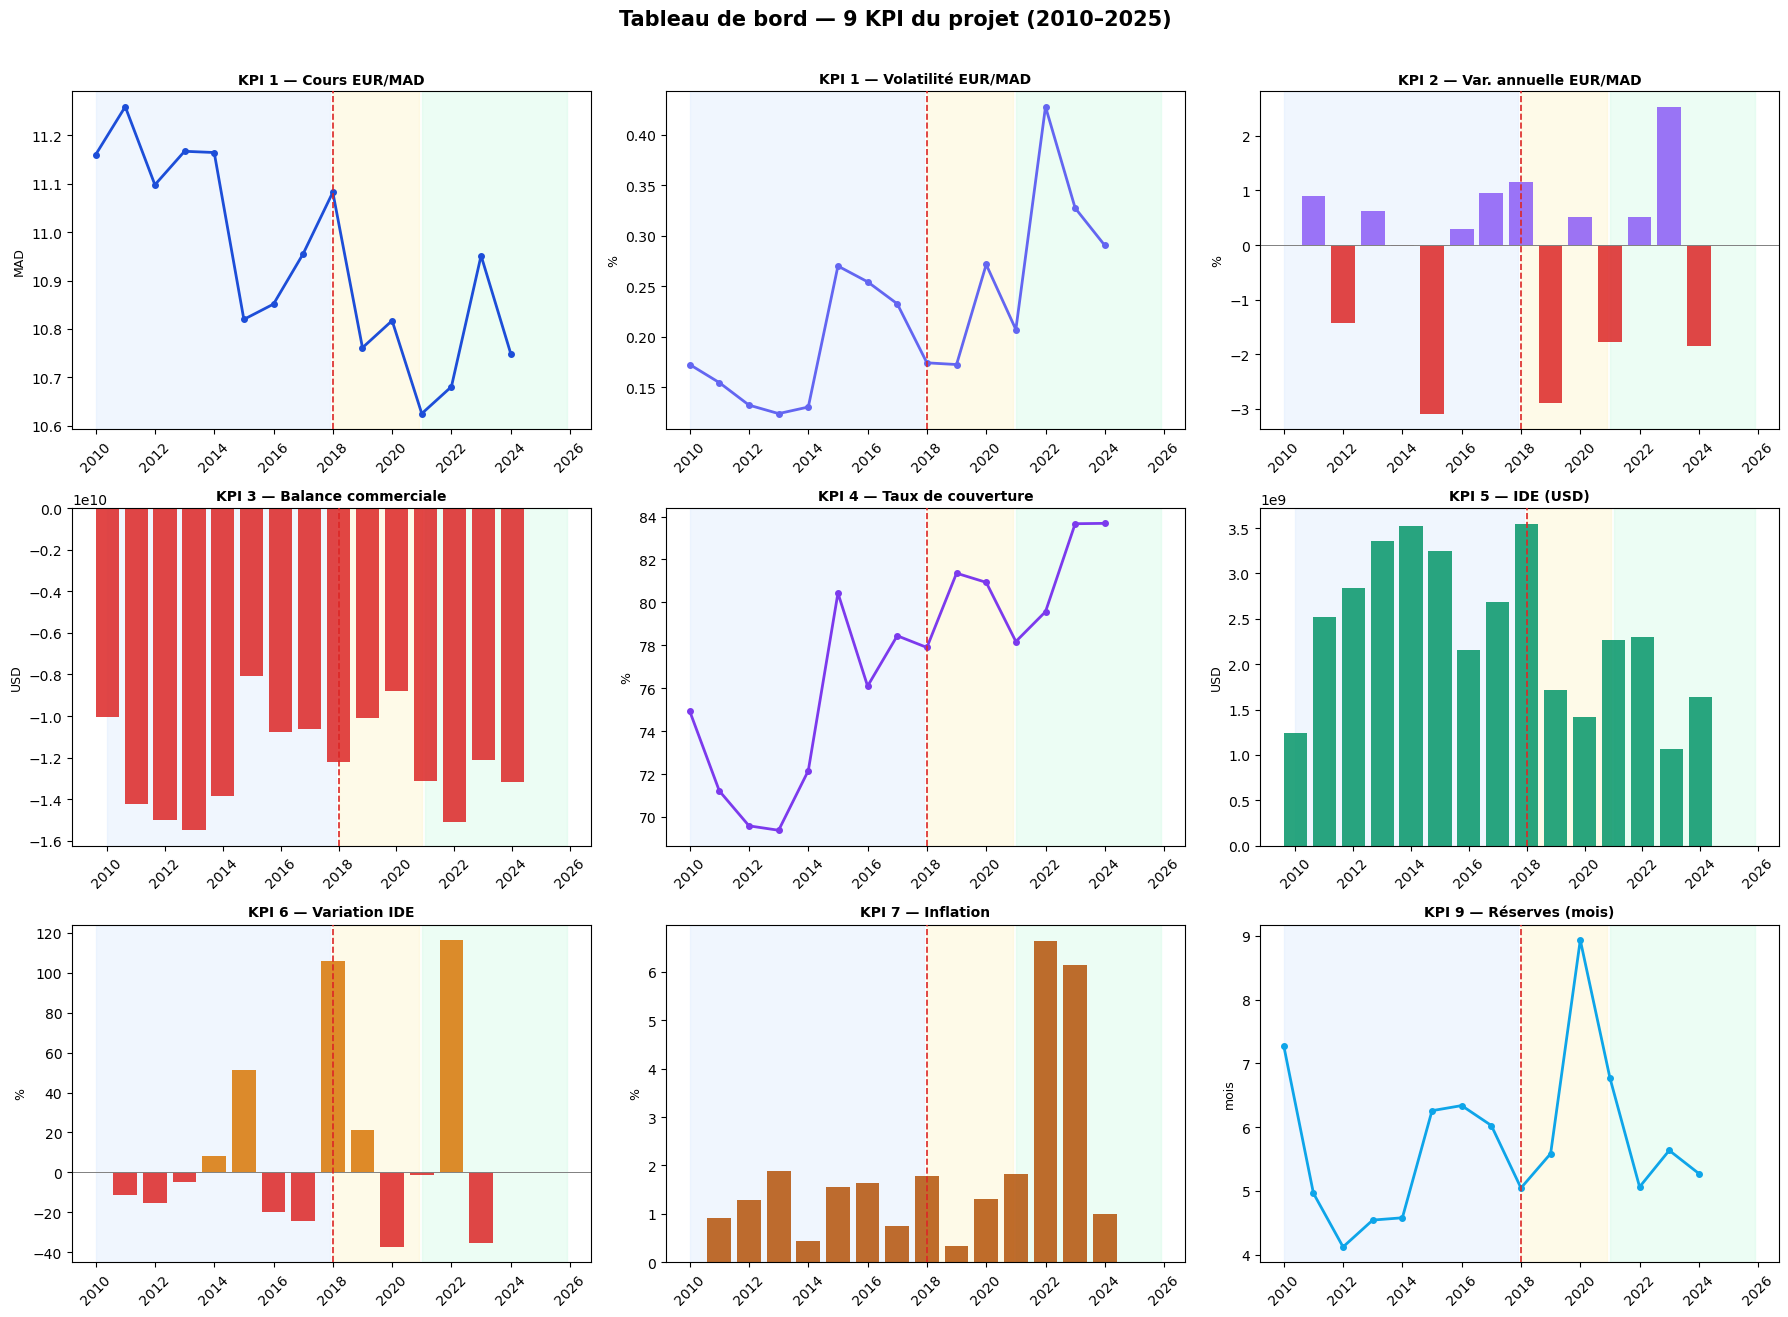

In [29]:
fig, axes = plt.subplots(3, 3, figsize=(18, 13))
fig.suptitle("Tableau de bord — 9 KPI du projet (2010–2025)",
             fontsize=15, fontweight='bold', y=1.01)

kpis_viz = [
    (axes[0,0], 'Year', 'EUR_MAD_moy',       'KPI 1 — Cours EUR/MAD',          '#1D4ED8', 'line', 'MAD'),
    (axes[0,1], 'Year', 'KPI1_Vol_EUR_ann',   'KPI 1 — Volatilité EUR/MAD',     '#6366F1', 'line', '%'),
    (axes[0,2], 'Year', 'KPI2_Var_EUR',       'KPI 2 — Var. annuelle EUR/MAD',  '#8B5CF6', 'bar',  '%'),
    (axes[1,0], 'Year', 'KPI3_Balance',       'KPI 3 — Balance commerciale',    '#DC2626', 'bar',  'USD'),
    (axes[1,1], 'Year', 'KPI4_Tx_Couv',       'KPI 4 — Taux de couverture',     '#7C3AED', 'line', '%'),
    (axes[1,2], 'Year', 'KPI5_IDE_USD',       'KPI 5 — IDE (USD)',              '#059669', 'bar',  'USD'),
    (axes[2,0], 'Year', 'KPI6_Var_IDE',       'KPI 6 — Variation IDE',          '#D97706', 'bar',  '%'),
    (axes[2,1], 'Year', 'KPI7_Inflation',     'KPI 7 — Inflation',              '#B45309', 'bar',  '%'),
    (axes[2,2], 'Year', 'KPI9_Mois_Couv',     'KPI 9 — Réserves (mois)',        '#0EA5E9', 'line', 'mois'),
]

for ax, xcol, ycol, title, color, chart_type, ylabel in kpis_viz:
    data = df_kpi.dropna(subset=[ycol])

    if chart_type == 'line':
        ax.plot(data[xcol], data[ycol],
                color=color, linewidth=2, marker='o', markersize=4)
    else:
        bar_cols = [color if v >= 0 else '#DC2626'
                    for v in data[ycol]]
        ax.bar(data[xcol], data[ycol],
               color=bar_cols, alpha=0.85)
        ax.axhline(0, color='gray', linewidth=0.7)

    add_bands(ax, is_date=False)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../visualisation/viz_kpi_dashboard.png", bbox_inches='tight', dpi=150)
plt.show()